
Матрица P^1000:
                 A          C          G          T
  A   0.333869   0.167164   0.160992   0.337975
  C   0.333869   0.167164   0.160992   0.337975
  G   0.333869   0.167164   0.160992   0.337975
  T   0.333869   0.167164   0.160992   0.337975

Все строки равны стационарному π:
  строка A: max|P1000[A,:] - π| = 3.94e-15
  строка C: max|P1000[C,:] - π| = 3.94e-15
  строка G: max|P1000[G,:] - π| = 3.94e-15
  строка T: max|P1000[T,:] - π| = 3.94e-15


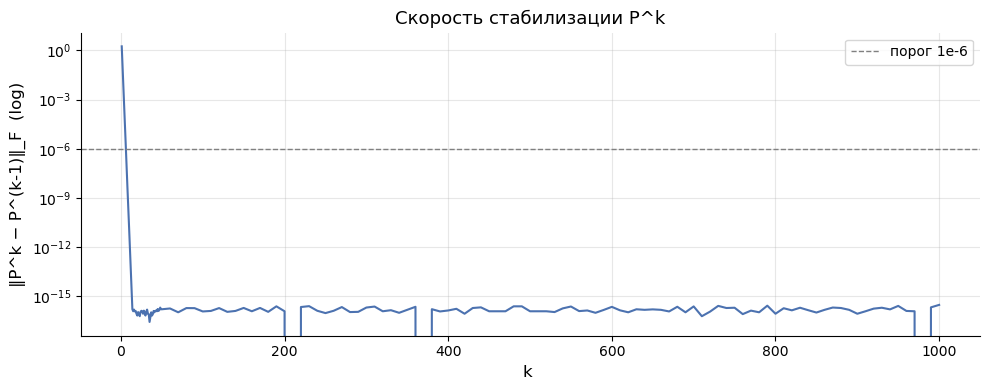

In [11]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
%matplotlib inline
 
NUCLEOTIDES = ["A", "C", "G", "T"]
NUC2IDX     = {n: i for i, n in enumerate(NUCLEOTIDES)}
FASTA_PATH  = "436.fasta.fa"
seq_parts = []
with open(FASTA_PATH) as f:
    for line in f:
        line = line.strip()
        if not line.startswith(">"):
            seq_parts.append(line.upper())
seq = "".join(seq_parts)
dinuc = np.zeros((4,4), dtype=int)
for k in range(len(seq)-1):
    a, b = seq[k], seq[k+1]
    if a in NUC2IDX and b in NUC2IDX:
        dinuc[NUC2IDX[a], NUC2IDX[b]] += 1
P = dinuc / dinuc.sum(axis=1, keepdims=True)
evals, evecs = np.linalg.eig(P.T)
idx = np.argmin(np.abs(evals - 1.0))
pi  = evecs[:, idx].real; pi /= pi.sum()

K_VALUES   = list(range(1, 51)) + list(range(50, 1001, 10))
K_VALUES   = sorted(set(K_VALUES))
norms      = []
P_prev     = np.eye(4)
for k in K_VALUES:
    Pk     = np.linalg.matrix_power(P, k)
    norm_k = np.linalg.norm(Pk - P_prev, "fro")
    norms.append(norm_k)
    P_prev = Pk
 
P1000 = np.linalg.matrix_power(P, 1000)
print("\nМатрица P^1000:")
print("         " + "  ".join(f"{n:>9}" for n in NUCLEOTIDES))
for i, ni in enumerate(NUCLEOTIDES):
    print(f"  {ni}  " + "  ".join(f"{P1000[i,j]:>9.6f}" for j in range(4)))
print("\nВсе строки равны стационарному π:")
for i, ni in enumerate(NUCLEOTIDES):
    diff = np.max(np.abs(P1000[i] - pi))
    print(f"  строка {ni}: max|P1000[{ni},:] - π| = {diff:.2e}")
 

fig, ax = plt.subplots(figsize=(10, 4))
ax.semilogy(K_VALUES, norms, color="#4C72B0", linewidth=1.5)
ax.axhline(1e-6, color="gray", linestyle="--", linewidth=1, label="порог 1e-6")
ax.set_xlabel("k ", fontsize=12)
ax.set_ylabel("‖P^k − P^(k-1)‖_F  (log)", fontsize=12)
ax.set_title("Скорость стабилизации P^k", fontsize=13)
ax.legend(); ax.grid(True, alpha=0.3)
ax.spines["top"].set_visible(False); ax.spines["right"].set_visible(False)
plt.tight_layout()
plt.show()